In [13]:
import matplotlib.pyplot as plt
import numpy as np
from functools import partial
import os
import copy
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import galsim
import pickle

from kl_pipe.parameters import ImagePars
from kl_pipe.source import SourceModel
from kl_pipe.velocity import CenteredVelocityModel
from kl_pipe.intensity import InclinedExponentialModel
from kl_pipe.lines import EmissionLine, LINE_LAMBDAS
from kl_pipe.observation import build_image_obs, build_velocity_obs, build_fiber_obs
from kl_pipe.noise import add_intensity_noise, add_fiberspec_noise
from kl_pipe.render import RenderConfig
from kl_pipe.fiber import FiberPars, build_fiber_pars_for_line
from kl_pipe.likelihood import _log_likelihood_fiber_source, create_jitted_likelihood_from_obs 
from kl_pipe.sampling.diagnostics import plot_corner, plot_trace, print_summary

In [69]:
folder_name = "/Users/laurenhwillett/Desktop/DESI_KL/fiber_likelihood_things/mcmc_results/numpyro_sm_17_param_realism_3fiber_1600_800_4_speedup"
os.mkdir(folder_name)

In [ ]:
# Joint source: velocity + one broadband band.
g_model = InclinedExponentialModel()
r_model = InclinedExponentialModel()
z_model = InclinedExponentialModel()
halpha_model = InclinedExponentialModel()
halpha_cont = InclinedExponentialModel()
joint_source = SourceModel(
    velocity_model=CenteredVelocityModel(),
    broadband_models={'g': g_model},#, 'r': r_model, 'z': z_model},
    emission_lines={'Halpha': EmissionLine(intensity=halpha_model, continuum=halpha_cont)},
)

z=0.058
true_pars = {
    'cosi': 0.4,
    'theta_int': 0.1*np.pi,
    'g1': 0.02,
    'g2': -0.01,
    'vel.v0': 0.0,
    'vel.vcirc': 200.0, #150.0,
    'vel.rscale': 3.12,
    'flux': 150.0,
    'rscale': 3.12, #3.0,
    'h_over_r': 0.1,
    'x0': 0.0,
    'y0': 0.0,
    'Halpha.flux': 120.0, #100.0
    'Halpha.rscale': 3.12, #3.12,
    'Halpha.h_over_r': 0.1,
    'Halpha.x0': 0.0,
    'Halpha.y0': 0.0,
    'Halpha.dispersion': 50.0,
    'Halpha.cont.flux_per_nm': 80.0, #8.0, #25.0, #flux per nm actually
    'Halpha.cont.rscale': 3.12, #3.12,
    'Halpha.cont.h_over_r': 0.1,
    'Halpha.cont.x0': 0.0,
    'Halpha.cont.y0': 0.0,
    'z': z,
}

#pixel_scale=0.2637 #check for DESI legacy survey what this should be
pixel_scale=0.262 #for DESI legacy survey this is apparently it
imagepars = ImagePars(shape=(251, 251), pixel_scale=pixel_scale, indexing='ij')
#imagepars = ImagePars(shape=(100, 100), pixel_scale=pixel_scale, indexing='ij') #cropped

phot_fwhm=1.2
phot_psf = galsim.Gaussian(phot_fwhm)
#rc = RenderConfig(oversample=5)
rc = RenderConfig(oversample=1, spectral_oversample=1) #for now

#broadband data (PSF-convolved).
#added noise into observation
#looks kinda noisy for SNR=100, 200 but what would I know
g_obs_clean = build_image_obs(imagepars, psf=phot_psf, render_config=rc,
                             int_model=g_model, broadband_key='g')
g_true = np.asarray(joint_source.render_broadband(true_pars, g_obs_clean, 'g'))
g_SNR = 300
g_noisy, g_var = add_intensity_noise(g_true, target_snr=g_SNR, seed=11)
g_obs = build_image_obs(imagepars, psf=phot_psf, render_config=rc, int_model=g_model,
                       broadband_key='g', data=jnp.asarray(g_noisy), variance=g_var)

#not using other filters yet
#r_obs_clean = build_image_obs(imagepars, psf=phot_psf, render_config=rc,
                             #int_model=r_model, broadband_key='r')
#r_true = np.asarray(joint_source.render_broadband(true_pars, r_obs_clean, 'r'))
#r_noisy, r_var = add_intensity_noise(r_true, target_snr=200, seed=12)
#r_obs = build_image_obs(imagepars, psf=phot_psf, render_config=rc, int_model=r_model,
                       #broadband_key='r', data=jnp.asarray(r_noisy), variance=r_var)

#z_obs_clean = build_image_obs(imagepars, psf=phot_psf, render_config=rc,
                             #int_model=z_model, broadband_key='r')
#z_true = np.asarray(joint_source.render_broadband(true_pars, z_obs_clean, 'r'))
#z_noisy, z_var = add_intensity_noise(z_true, target_snr=200, seed=13)
#z_obs = build_image_obs(imagepars, psf=phot_psf, render_config=rc, int_model=z_model,
                       #broadband_key='z', data=jnp.asarray(z_noisy), variance=z_var)

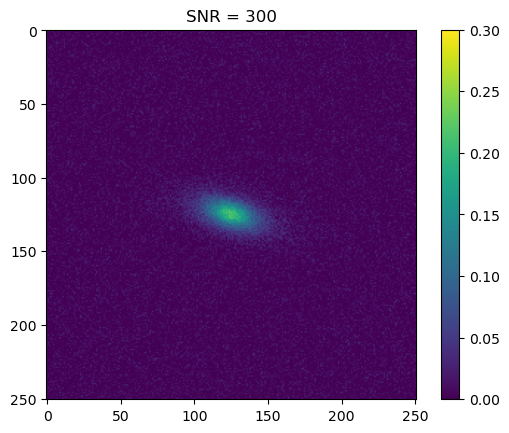

In [70]:
plt.imshow(g_noisy, vmin=0, vmax=0.3)
plt.title('SNR = '+ str(g_SNR))
plt.colorbar()
plt.savefig(folder_name+'/g_image.png')

#this is just a mess, honestly

def elliptical_mask(
    shape,
    x0,
    y0,
    semi_major,
    axis_ratio,
    position_angle_deg,
):
    """
    Construct an elliptical aperture mask.

    position_angle_deg is measured counterclockwise from the +x axis.
    """
    y, x = np.indices(shape, dtype=float)

    theta = np.deg2rad(position_angle_deg)

    dx = x - x0
    dy = y - y0

    x_major = dx * np.cos(theta) + dy * np.sin(theta)
    y_minor = -dx * np.sin(theta) + dy * np.cos(theta)

    semi_minor = semi_major * axis_ratio

    elliptical_radius_squared = (
        (x_major / semi_major) ** 2
        + (y_minor / semi_minor) ** 2
    )

    return elliptical_radius_squared <= 1.0

galaxy_mask = elliptical_mask(
    shape=g_noisy.shape,
    x0=125.5,
    y0=125.5,
    semi_major=60.0,
    axis_ratio=0.45,
    position_angle_deg=50.0)

noise_mask = elliptical_mask(
    shape=g_noisy.shape,
    x0=125.5,
    y0=125.5,
    semi_major=70.0,
    axis_ratio=0.45,
    position_angle_deg=50.0,
)
noise_mask = ~noise_mask

plt.imshow(g_noisy)
plt.colorbar()
plt.show()

plt.imshow(g_noisy*galaxy_mask)
plt.colorbar()
plt.show()

plt.imshow(g_noisy*noise_mask)
plt.colorbar()
plt.show()

stddev= np.std(g_noisy*noise_mask)
print('stddev', stddev)
background = np.median(g_noisy*noise_mask)
source_flux = np.sum(g_noisy*galaxy_mask - background)
n_source = (g_noisy*galaxy_mask).size
n_background = (g_noisy*noise_mask).size
flux_variance = stddev**2 * (n_source + ((np.pi/2)*(n_source**2 / n_background)))
flux_error = np.sqrt(flux_variance)
SNR_est = source_flux / flux_error
print('est SNR', SNR_est) #this seems bad

invvar_approx = (1/stddev)**2
snr_squared = np.sum(g_noisy**2 * invvar_approx)
print(np.sqrt(snr_squared))

In [17]:
#need to make fiber pars and fiber obs
fiber_blur = 3.4 # pixels
#atm_psf_fwhm = 1.0 # arcsec, not being used anywhere it seems. yes because i am using the same PSF as for the image above. although in practice that may not always be the case
spec_fwhm=1.2
spec_psf = galsim.Gaussian(spec_fwhm)

fiber_rad = 0.75 # arcsec --> verified
fiber_offset = 15.75105607509613*0.4 #6.5 #1.5 # arcsec (distance between fibers and center) ---> probably depends on the observation? yes
#SPEC_MASK=1
EXP_OFFSET=600
SCR_DIR = '/Users/laurenhwillett/Desktop/DESI_KL/kl_roman_pipe_2/kl_roman_pipe/' #to get data folder
chn = 'r' #this is the channel for the spectrum. needs to encompass redshifted H-alpha line

#default_conf = { #'OBSTYPE': 1,
    #'SKYMODEL': SCR_DIR+"data/Skyspectra/spec-sky.dat",
    #'DIAMETER': 332.42, 'EXPTIME': 180, 'GAIN': 1.0,
    #'FIBERRAD': fiber_rad, 'FIBRBLUR': fiber_blur
#}
#3.8 meter diameter for primary mirror? Where did 3.3 come from?

#default_obs_conf, _index_ = [], 0
#rdn=2.6


#assert SPEC_MASK < 2**(len(emlines)), f'Maximum SPEC_MASK allow by {len(emlines)} emission lines: {2**(len(emlines))-1}'
#spec_mask_str = ("{0:0%db}"%len(emlines)).format(SPEC_MASK)
#spec_mask = np.array([int(bit) for bit in spec_mask_str])
#Nspec_used = np.sum(spec_mask)
#blockids = [int(np.sum(spec_mask[:i])*spec_mask[i]) for i in range(len(spec_mask))]
#print(f'spec mask = {spec_mask}')
#print(f'block id = {blockids}')
### Choose fiber configurations
fiberconf=1
if fiberconf==0:
    offsets = [(fiber_offset*np.cos(0+true_pars['cosi']),         fiber_offset*np.sin(0+true_pars['cosi'])),
               (fiber_offset*np.cos(np.pi/2+true_pars['cosi']),   fiber_offset*np.sin(np.pi/2+true_pars['cosi'])),
               (fiber_offset*np.cos(np.pi+true_pars['cosi']),   fiber_offset*np.sin(np.pi+true_pars['cosi'])),
               (fiber_offset*np.cos(3*np.pi/2+true_pars['cosi']), fiber_offset*np.sin(3*np.pi/2+true_pars['cosi'])),
               (0,0)]
    OFFSETX = 1
elif fiberconf==1:
    offsets = [(fiber_offset*np.cos(0),         fiber_offset*np.sin(0)),
               (fiber_offset*np.cos(np.pi),   fiber_offset*np.sin(np.pi)),
               (0,0)]
    OFFSETX = 2
elif fiberconf==2:
    offsets = [(fiber_offset*np.cos(np.pi/2),   fiber_offset*np.sin(np.pi/2)),
               (fiber_offset*np.cos(3*np.pi/2), fiber_offset*np.sin(3*np.pi/2)),
               (0,0)]
    OFFSETX = 2
elif fiberconf==3:
    offsets = [(fiber_offset*np.cos(0),         fiber_offset*np.sin(0)),
               (fiber_offset*np.cos(np.pi/2),   fiber_offset*np.sin(np.pi/2)),
               (0,0)]
    OFFSETX = 2
else:
    print(f'Fiber configuration case {fiberconf} is not implemented yet!')
    exit(-1)

#make my own
theta_int_angle = true_pars['theta_int']
R = np.array([[np.cos(theta_int_angle), -np.sin(theta_int_angle)],
              [np.sin(theta_int_angle), np.cos(theta_int_angle)]])
#offsets_og = [(fiber_offset*np.cos(np.pi),   fiber_offset*np.sin(np.pi)),
            #(0,0)]\
rotated_offsets = []
for offset_og in offsets:
    rotated_offsets.append(tuple(np.matmul(R,offset_og)))
#print(offsets_og)
#print(offsets)
#OFFSETX = 2

#for i in range(len(emlines)):
    #if spec_mask[i]==1:
        #eml, bid, chn, rdn = emlines[i], blockids[i], channels[i], rdnoise[i]   

#fiber_exptimes = []
_bp = SCR_DIR+"data/Bandpass/DESI/%s.dat"%(chn)
#for (dx, dy) in rotated_offsets:
    #print("\n==== Adding Observation %d: spectra"%(_index_))
    #_conf = copy.deepcopy(default_conf)
    #_conf.update({'OBSINDEX': _index_, 'BANDPASS': _bp})
                #'RDNOISE': rdn})#, 'FIBERDX': dx, 'FIBERDY': dy
    #if np.abs(dx)>1e-3 or np.abs(dy)>1e-3:
        #_conf.update({'EXPTIME': EXP_OFFSET*OFFSETX}) #the off-center exposures are longer, it seems
    #print(f'offset = ({dx:.2f}, {dy:.2f}); EXPTIME = {_conf["EXPTIME"]} s')
    #fiber_exptimes.append(_conf["EXPTIME"])
    #default_obs_conf.append(_conf)
    #_index_+=1


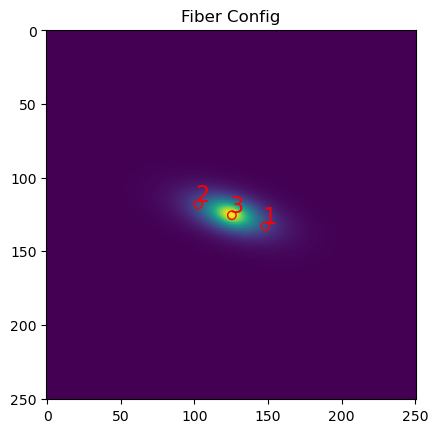

In [71]:
ax = plt.figure().add_subplot()
ax.imshow(g_true)
pixscale = pixel_scale

from matplotlib import patches

for j in range(len(rotated_offsets)):
    x, y = rotated_offsets[j]
    x = x/pixscale + imagepars.shape[0]/2
    y = y/pixscale + imagepars.shape[0]/2
    offsetpos = (x,y)
    fiber = patches.Circle(offsetpos, 0.75/pixscale, color='red', fill=False)
    ax.add_patch(fiber)
    #ax.text(x-0.75, y+0.75, str(j+1), fontsize=16, color='red')
    ax.text(x-2, y-2, str(j+1), fontsize=16, color='red')

plt.title('Fiber Config')
#plt.xlim(imagepars.shape[0]/3, 2*imagepars.shape[0]/3)
#plt.ylim(imagepars.shape[0]/3, 2*imagepars.shape[0]/3)

plt.savefig(folder_name+'/fiber_config.png')
plt.show()

In [45]:
z=true_pars['z']

#_IMAGE_PARS_spec = ImagePars(shape=(64, 64), pixel_scale=0.11, indexing='ij') # pixel_scale= arcsec/pixel
#_IMAGE_PARS_spec = ImagePars(shape=(251, 251), pixel_scale=0.11, indexing='ij') # pixel_scale= arcsec/pixel
#_IMAGE_PARS_spec = ImagePars(shape=(200, 200), pixel_scale=0.11, indexing='ij') # pixel_scale= arcsec/pixel
_IMAGE_PARS_spec = ImagePars(shape=(100, 100), pixel_scale=0.22, indexing='ij') # pixel_scale= arcsec/pixel
fiberpars_instances = []
fiberobs_instances = []
rendered_spectra = []
for i in range(0, len(rotated_offsets)):
    #obs_conf = default_obs_conf[i]
    fiberpars_instance = build_fiber_pars_for_line(
        lambda_rest = LINE_LAMBDAS['Halpha'], redshift=z, delta_lambda=0.1, image_pars=_IMAGE_PARS_spec, fiber_radius=fiber_rad, fiber_blur = fiber_blur, fiber_dx=rotated_offsets[i][0], fiber_dy=rotated_offsets[i][1], bandpass_path = _bp)
    fiberobs_instance = build_fiber_obs(fiberpars_instance, z, psf=spec_psf, render_config=rc)
    rendered_spec = joint_source.render_fiber(pars = true_pars, obs=fiberobs_instance)#, spectral_oversample=1.0)
    fiberpars_instances.append(fiberpars_instance)
    fiberobs_instances.append(fiberobs_instance)
    rendered_spectra.append(rendered_spec)

#I just need one of these for all the spectra
cubepars_instance = fiberobs_instance.cube_pars

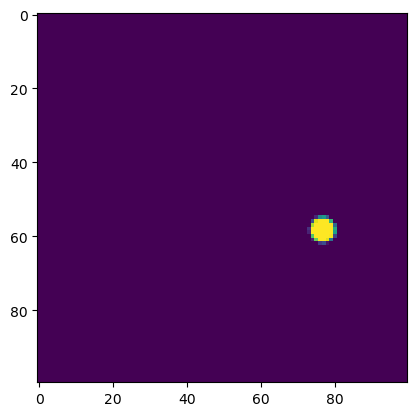

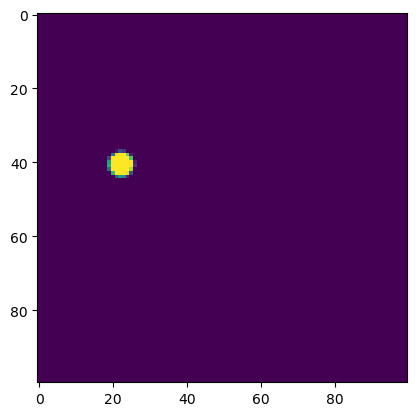

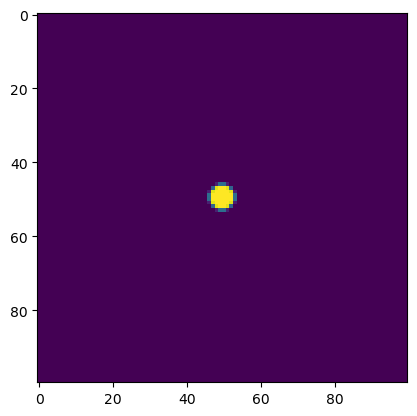

In [46]:
from kl_pipe.observation import get_fiber_mask, precompute_PSF_convolved_fiber_mask
oversample=1

if oversample > 1:
    fine_image_pars = cubepars_instance.image_pars.make_fine_scale(oversample)
    # precompute BoxPixel sinc on fine k-grid for post-dispersion pixel
    # response (consumed by KLModel.render_grism). pixel response is a
    # coarse-detector property; sinc uses the coarse pixel_scale.
    coarse_ps = cubepars_instance.image_pars.pixel_scale
    fine_ps = fine_image_pars.pixel_scale
    Nrow_f, Ncol_f = fine_image_pars.Nrow, fine_image_pars.Ncol
if oversample == 1:
    fine_image_pars = cubepars_instance.image_pars

for fiberpars_instance in fiberpars_instances:
    plt.imshow(get_fiber_mask(fine_image_pars, fiberpars_instance))
    plt.show()

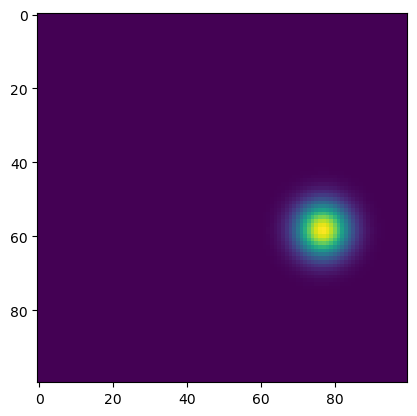

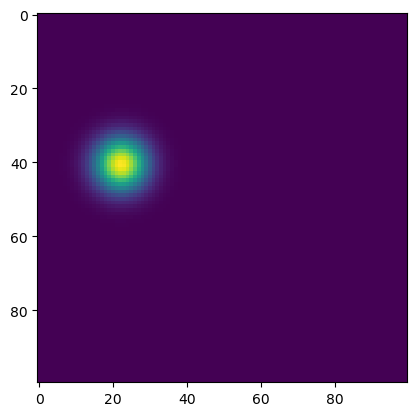

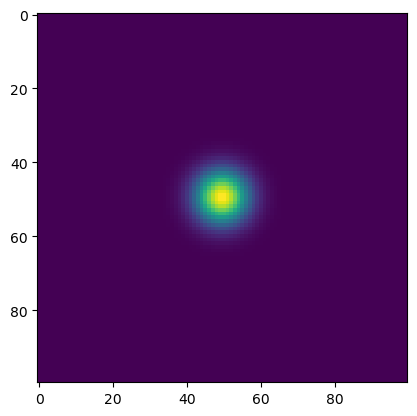

In [47]:
for fiberobs_instance in fiberobs_instances:
    plt.imshow(fiberobs_instance.ATMPSF_conv_fiber_mask)
    plt.show()

In [48]:
from kl_pipe.observation import group_fiber_obs
fiberobs_groups = group_fiber_obs({'fiber0': fiberobs_instances[0], 'fiber1': fiberobs_instances[1], 'fiber2': fiberobs_instances[2]})

In [49]:
#time this
import time
start = time.time()
for i in range(0, 100):
    multiple_spectra = joint_source.render_fiber_group(pars = true_pars, obs_group=fiberobs_groups[0]) 
end = time.time()
print((end-start)/100)

0.03201680183410645


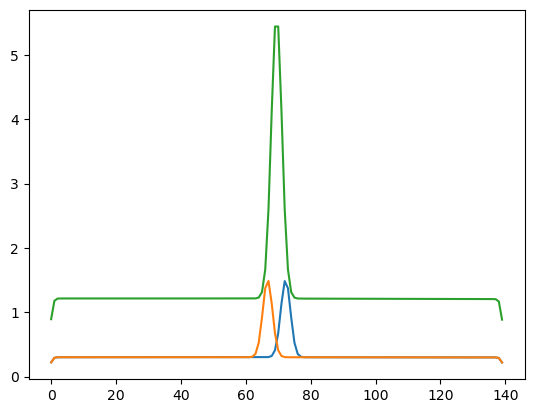

In [50]:
for key, spectrum in multiple_spectra.items():
    plt.plot(spectrum)

[0.00762849 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849
 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849
 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849
 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849
 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849
 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849
 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849
 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849
 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849
 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849
 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849
 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849
 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849
 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849
 0.00762849 0.00762849 0.00762849 0.00762849 0.00762849 0.0076

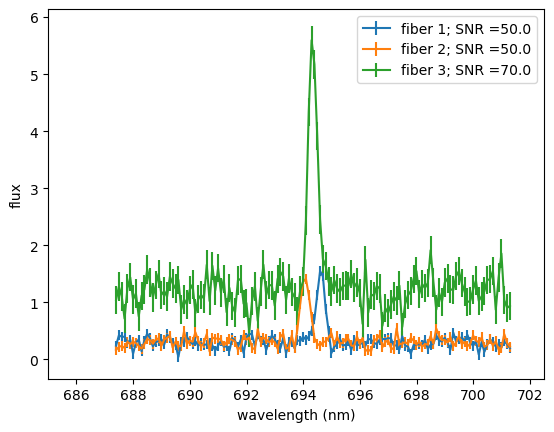

In [72]:
#if the fibers have different exposure times, then they'll have a different SNR

SNRs=[50.0, 50.0, 70.0]
fiberspectra_noisy = []
fiberspectra_var = []

#for i in range(0, len(multiple_spectra)):
#for key, spectrum in multiple_spectra.items():
for i in range(0, len(rendered_spectra)):
    rendered_spec = rendered_spectra[i]
    SNR = SNRs[i]
    fiberspec_noisy, fiberspec_var = add_fiberspec_noise(rendered_spec, SNR, include_poisson=False) #include_poisson=True
    print(fiberspec_var)
    fiberspectra_noisy.append(fiberspec_noisy)
    fiberspectra_var.append(fiberspec_var)
    
    plt.errorbar(cubepars_instance.lambda_grid, fiberspec_noisy, yerr = np.sqrt(fiberspec_var), label='fiber '+ str(i+1)+ '; SNR =' + str(SNR))
    plt.xlabel('wavelength (nm)')
    plt.ylabel('flux')
    plt.xlim(685, 702.5)
    #plt.title('SNR = '+ str(SNR))
    plt.legend()

plt.savefig(folder_name+'/fiber_spectra.png')

In [52]:
#now I need to make an obs that has the data and variance in it
fiberobs_spectra = []
for i in range(0, len(fiberspectra_noisy)):
    data = fiberspectra_noisy[i]
    var = fiberspectra_var[i]
    fiberpars = fiberpars_instances[i]
    obs = build_fiber_obs(fiberpars, z, data=data, variance=var, psf=spec_psf, render_config=rc)
    fiberobs_spectra.append(obs)

#group them up
from kl_pipe.observation import group_fiber_obs
fiberobs_spectra_groups = group_fiber_obs({'fiber0': fiberobs_spectra[0], 'fiber1': fiberobs_spectra[1], 'fiber2': fiberobs_spectra[2]})

In [53]:
fiberobs_spectra_groups[0]

{'fiber0': FiberObs(fiber_pars=FiberPars(image_pars=<kl_pipe.parameters.ImagePars object at 0x35c84f050>, lambda_ref=694.34424, delta_lambda=0.1, fiber_radius=0.75, fiber_blur=3.4, fiber_dx=np.float64(5.992057807500216), fiber_dy=np.float64(1.9469376026229848), bandpass_path='/Users/laurenhwillett/Desktop/DESI_KL/kl_roman_pipe_2/kl_roman_pipe/data/Bandpass/DESI/r.dat', throughput=None), cube_pars=CubePars(image_pars=<kl_pipe.parameters.ImagePars object at 0x35c84f050>, lambda_grid=Array([687.39599075, 687.49596556, 687.59594037, 687.69591518,
        687.79588999, 687.8958648 , 687.99583961, 688.09581442,
        688.19578923, 688.29576404, 688.39573885, 688.49571366,
        688.59568847, 688.69566328, 688.79563808, 688.89561289,
        688.9955877 , 689.09556251, 689.19553732, 689.29551213,
        689.39548694, 689.49546175, 689.59543656, 689.69541137,
        689.79538618, 689.89536099, 689.9953358 , 690.09531061,
        690.19528541, 690.29526022, 690.39523503, 690.49520984,
   

In [54]:
#build InferenceTask from obs
from kl_pipe.priors import PriorDict, Uniform, Gaussian, TruncatedNormal
from kl_pipe.sampling import InferenceTask


priors = PriorDict({
    'cosi': TruncatedNormal(0.4, 0.15, 0.05, 0.99),
    'theta_int': TruncatedNormal(0.1*np.pi, 0.3, 0.01, np.pi / 2),
    'g1': Uniform(-0.25, 0.25), #0.02,
    'g2': Uniform(-0.25, 0.25), #-0.01,
    'vel.v0': Gaussian(0.0, 10.0), #0.0,
    'vel.vcirc': TruncatedNormal(200.0, 80.0, 50.0, 550.0),   # TF prior
    'vel.rscale': Uniform(0.1, 5.0),
    'flux': TruncatedNormal(150.0, 20.0, 30.0, 250.0),
    'rscale': Uniform(0.1, 5.0),
    'h_over_r': true_pars['h_over_r'],                                     # fixed (low observable sensitivity)
    'x0': TruncatedNormal(0.0, 0.1, -0.5, 0.5), #0.0,
    'y0': TruncatedNormal(0.0, 0.1, -0.5, 0.5), #0.0,
    'Halpha.flux': TruncatedNormal(120.0, 20.0, 30.0, 250.0), #100.0
    'Halpha.rscale': Uniform(0.1, 5.0), #2.0,
    'Halpha.h_over_r': true_pars['Halpha.h_over_r'],                                   # fixed
    'Halpha.x0': TruncatedNormal(0.0, 0.1, -0.5, 0.5), #0.0,
    'Halpha.y0': TruncatedNormal(0.0, 0.1, -0.5, 0.5), #0.0,
    'Halpha.dispersion': TruncatedNormal(50.0, 20.0, 5.0, 150.0), #50.0,
    'Halpha.cont.flux_per_nm': TruncatedNormal(80.0, 15.0, 0.01, 200.0), #25.0,  #change to flux per nm?
    'Halpha.cont.rscale': true_pars['Halpha.cont.rscale'],   # fixed to line truth
    'Halpha.cont.h_over_r': true_pars['Halpha.cont.h_over_r'],
    'Halpha.cont.x0': true_pars['Halpha.cont.x0'],
    'Halpha.cont.y0': true_pars['Halpha.cont.y0'],
    'z': true_pars['z'],                                                   # fixed
})

task = InferenceTask.from_obs(
    joint_source, priors,
    image_obs={'g': g_obs},
    fiber_obs = fiberobs_spectra_groups[0], spectral_oversample=1)
    #fiber_obs={'fiber0': fiberobs_spectra_group[0], 'fiber1': fiberobs_spectra_group[1], 'fiber2': fiberobs_spectra_group[2]}, spectral_oversample=1)
    #fiber_obs={'fiber0': fiberobs_spectra[0], 'fiber1': fiberobs_spectra[1], 'fiber2': fiberobs_spectra[2], 'fiber3': fiberobs_spectra[3], 'fiber4': fiberobs_spectra[4]}, spectral_oversample=1)

In [55]:
theta_true = []
for name in task.sampled_names:
    theta_true.append(true_pars[name])
theta_true = jnp.array(theta_true)
print(theta_true)

[ 8.00000000e+01  5.00000000e+01  1.20000000e+02  3.12000000e+00
  0.00000000e+00  0.00000000e+00  4.00000000e-01  1.50000000e+02
  2.00000000e-02 -1.00000000e-02  3.12000000e+00  3.14159265e-01
  3.12000000e+00  0.00000000e+00  2.00000000e+02  0.00000000e+00
  0.00000000e+00]


In [56]:
from kl_pipe.likelihood import _log_likelihood_fiber_group_source

#three fibers
start = time.time()
_log_likelihood_fiber_group_source(
    theta_sampled = theta_true,
    source = joint_source,
    obs_group = fiberobs_spectra_groups[0],
    sampled_names = task.sampled_names,
    fixed_pars = task.fixed_params,
    spectral_oversample=1)
end = time.time()
print(end-start)

0.05091714859008789


In [57]:
from kl_pipe.likelihood import _log_likelihood_total_source

#three fibers
start = time.time()
_log_likelihood_total_source(
    theta_sampled = theta_true,
    source = joint_source,
    image_obs = None,
    grism_obs = None,
    velocity_obs = None,
    #fiber_obs = {'fiber0': fiberobs_spectra[0], 'fiber1': fiberobs_spectra[1], 'fiber2': fiberobs_spectra[2]},
    fiber_obs = None,
    fiber_groups= fiberobs_spectra_groups,
    sampled_names = task.sampled_names,
    fixed_pars = task.fixed_params,
    spectral_oversample=1)
end = time.time()
print(end-start)

0.04934096336364746


In [58]:
sampled_names = []
fixed_params = []

jitted_likelihood = create_jitted_likelihood_from_obs(joint_source, sampled_names = task.sampled_names, fixed_pars = task.fixed_params, image_obs = {'g': g_obs}, fiber_obs= fiberobs_spectra_groups[0], spectral_oversample=1)
#jitted_likelihood = create_jitted_likelihood_from_obs(joint_source, sampled_names = task.sampled_names, fixed_pars = task.fixed_params, image_obs = {'g': g_obs}, fiber_groups = fiberobs_spectra_groups, spectral_oversample=1)

#timed likelihood
import time
start = time.time()
print(jitted_likelihood(theta_true))
for i in range(0,100):
    jitted_likelihood(theta_true)
end = time.time()
print((end-start)/100)

191393.32289065156
0.007282700538635254


In [60]:
import jax
import jax.numpy as jnp

loglike = jitted_likelihood(theta_true)
grad = jax.grad(jitted_likelihood)(theta_true)

print("loglike =", loglike)
print("finite likelihood?", jnp.isfinite(loglike))
print("gradient =", grad)
print("finite gradient?", jnp.all(jnp.isfinite(grad)))

loglike = 191393.32289065156
finite likelihood? True
gradient = [-4.87947638e-01  3.46948823e-01 -1.99661615e-01  6.63740142e+00
 -9.97303798e-01 -3.73466665e-01 -8.15851322e+01 -2.37571144e+00
  1.34049988e+02  2.73297518e+02  2.16151758e+01  1.00533246e+02
  7.14706882e+00 -5.91007060e-01 -3.28503548e-01  2.07577947e+01
 -7.48654397e+01]
finite gradient? True


In [61]:
value, grad = jax.value_and_grad(jitted_likelihood)(theta_true)

for name, x, g in zip(task.sampled_names, theta_true, grad):
    print(f"{name:15s} value={x: .6g} grad={g: .6g}")

Halpha.cont.flux_per_nm value= 80 grad=-0.487948
Halpha.dispersion value= 50 grad= 0.346949
Halpha.flux     value= 120 grad=-0.199662
Halpha.rscale   value= 3.12 grad= 6.6374
Halpha.x0       value= 0 grad=-0.997304
Halpha.y0       value= 0 grad=-0.373467
cosi            value= 0.4 grad=-81.5851
flux            value= 150 grad=-2.37571
g1              value= 0.02 grad= 134.05
g2              value=-0.01 grad= 273.298
rscale          value= 3.12 grad= 21.6152
theta_int       value= 0.314159 grad= 100.533
vel.rscale      value= 3.12 grad= 7.14707
vel.v0          value= 0 grad=-0.591007
vel.vcirc       value= 200 grad=-0.328504
x0              value= 0 grad= 20.7578
y0              value= 0 grad=-74.8654


In [62]:
def finite_difference(f, x, i, h=1e-5):
    dx = jnp.zeros_like(x).at[i].set(h)
    return (f(x + dx) - f(x - dx)) / (2 * h)

jax_grad = jax.grad(jitted_likelihood)(theta_true)

for i, name in enumerate(task.sampled_names):
    fd_grad = finite_difference(jitted_likelihood, theta_true, i)
    print(name, "JAX:", jax_grad[i], "finite diff:", fd_grad)

Halpha.cont.flux_per_nm JAX: -0.48794763759720405 finite diff: -0.48794754547998304
Halpha.dispersion JAX: 0.346948823186003 finite diff: 0.3469496732577681
Halpha.flux JAX: -0.19966161546031574 finite diff: -0.1996610080823302
Halpha.rscale JAX: 6.637401415274679 finite diff: 6.6374021116644135
Halpha.x0 JAX: -0.9973037984451943 finite diff: -0.9973038686439394
Halpha.y0 JAX: -0.37346666454604005 finite diff: -0.373467628378421
cosi JAX: -81.5851322202461 finite diff: -81.58511336660013
flux JAX: -2.3757114433208857 finite diff: -2.375710755586624
g1 JAX: 134.0499878981086 finite diff: 134.04998753685504
g2 JAX: 273.2975177407505 finite diff: 273.29752047080547
rscale JAX: 21.615175844883552 finite diff: 21.615176228806376
theta_int JAX: 100.53324583160085 finite diff: 100.53324658656491
vel.rscale JAX: 7.147068819903147 finite diff: 7.147068390622734
vel.v0 JAX: -0.5910070597771602 finite diff: -0.5910071195103228
vel.vcirc JAX: -0.3285035475945433 finite diff: -0.32850366551429033
x

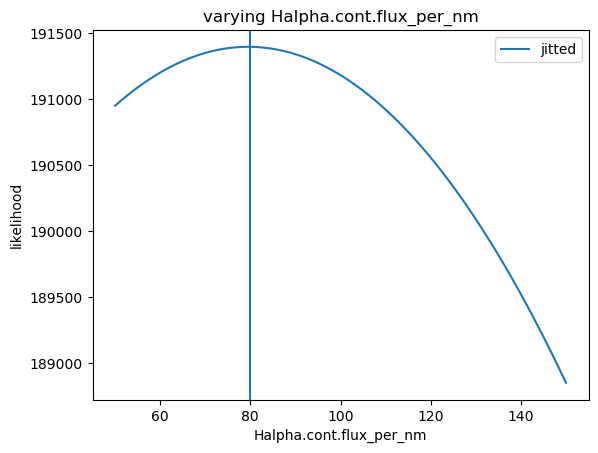

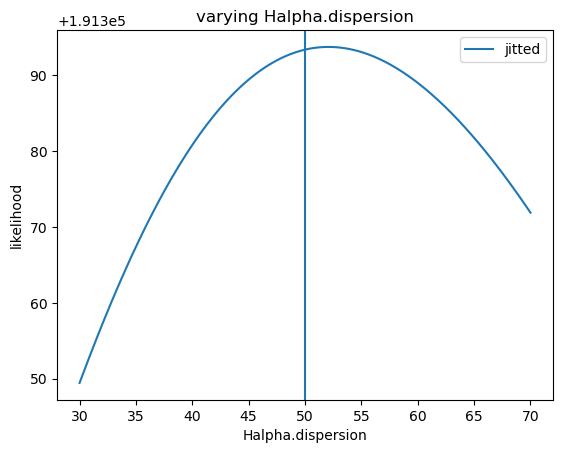

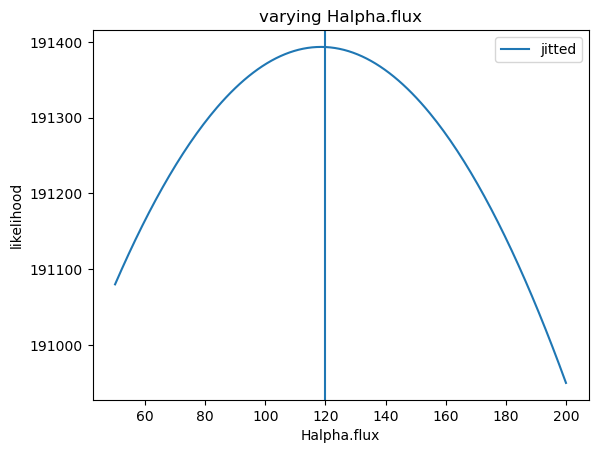

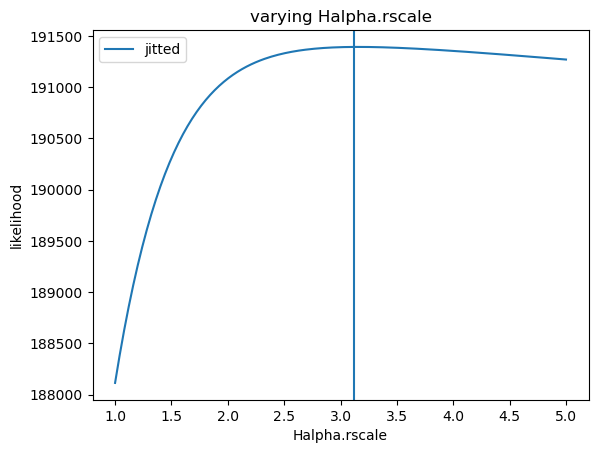

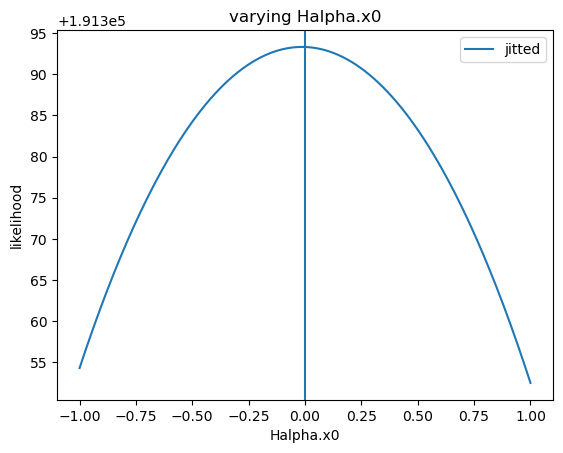

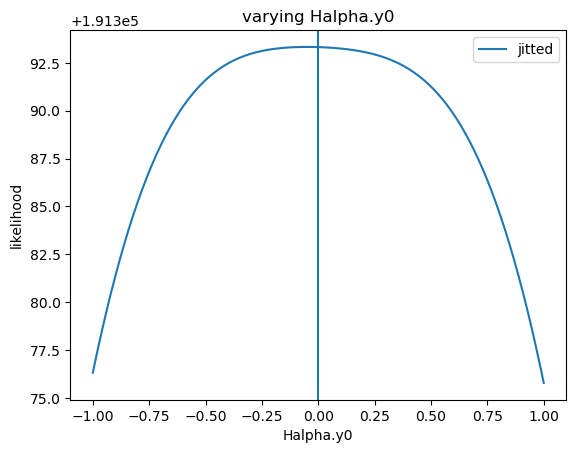

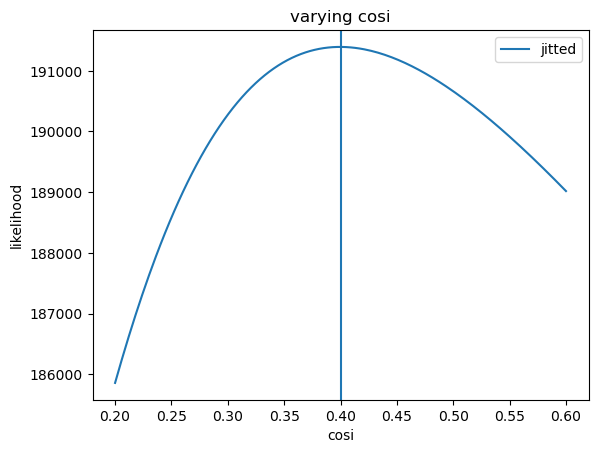

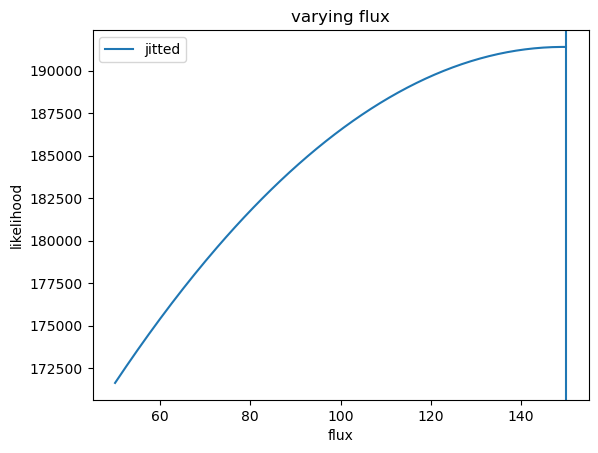

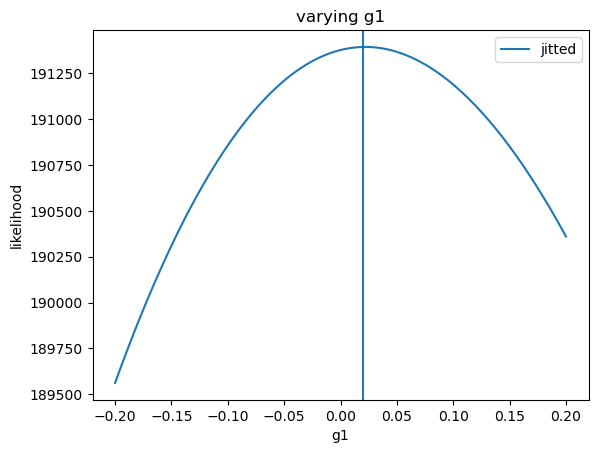

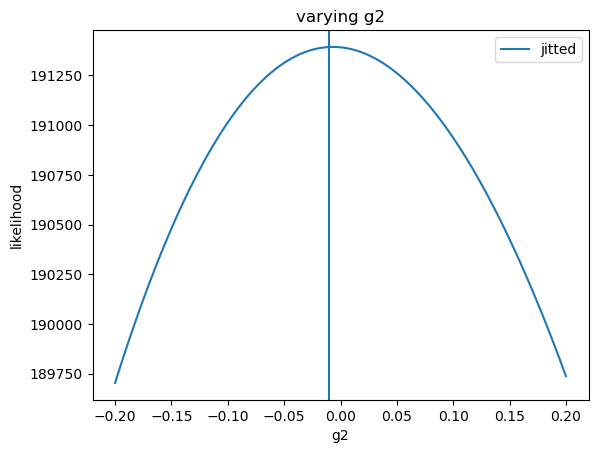

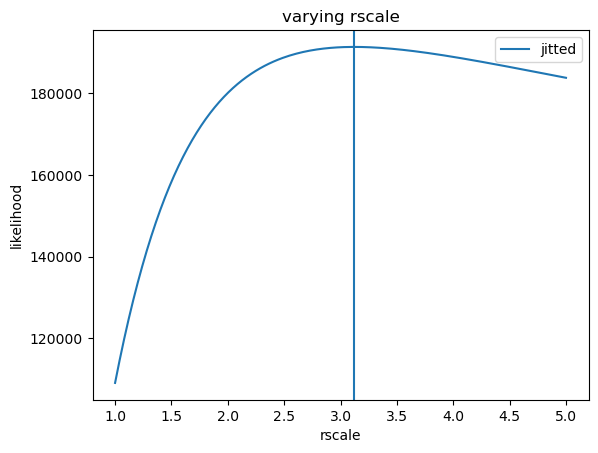

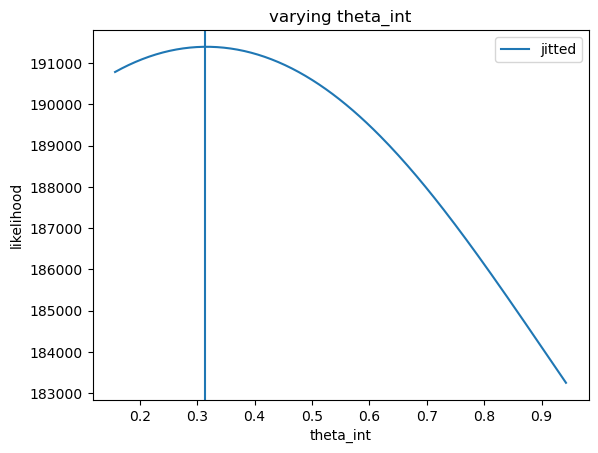

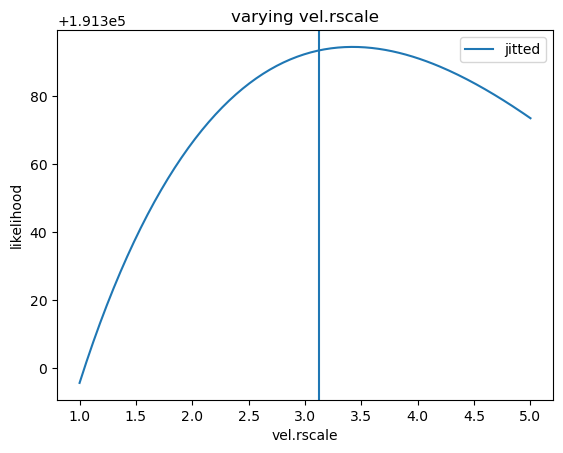

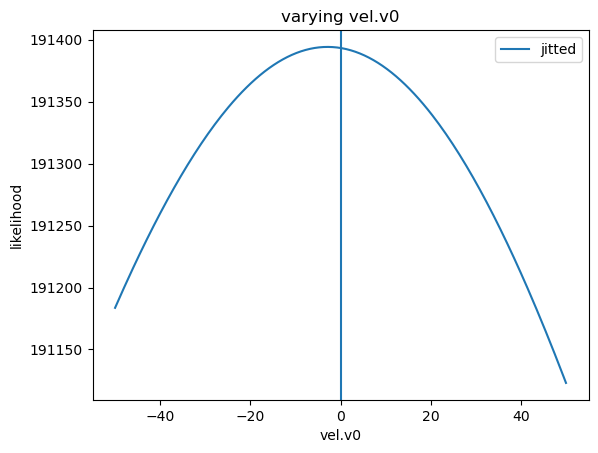

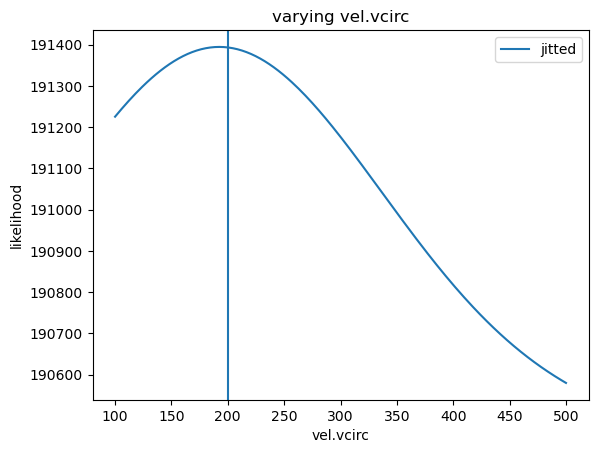

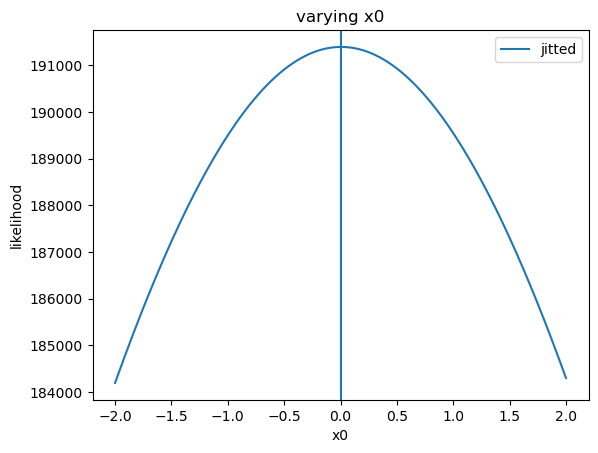

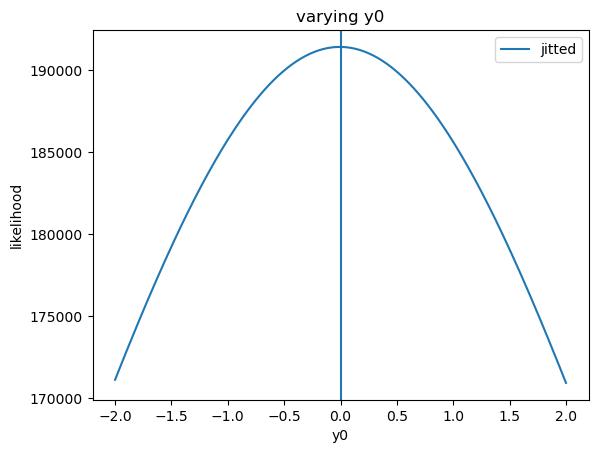

In [ ]:
#I should do some likelihood slice test -- priors ordered
names=task.sampled_names
ranges = [(50.0,150.0), (30.0,70.0), (50.0,200.0), (1.0,5.0), (-1.0, 1.0), (-1.0, 1.0), (0.2, 0.6), (50.0,150.0), (-0.2, 0.2), (-0.2, 0.2), (1.0,5.0),  (0.05*np.pi, 0.3*np.pi), (1.0,5.0), (-50.0, 50.0), (100,500), (-2,2), (-2,2)]
for i in range(0,len(theta_true)):
    range_param = ranges[i]
    central = theta_true[i]
    test_vals = np.linspace(range_param[0], range_param[1], 200)
    theta_thing = np.copy(theta_true)
    likelihoods_jitted = []
    for val in test_vals:
        theta_thing[i] = val
        likelihood_jitted_thing = jitted_likelihood(jnp.array(theta_thing))
        likelihoods_jitted.append(likelihood_jitted_thing)
    plt.plot(test_vals, likelihoods_jitted, label='jitted')
    plt.axvline(x=central)
    plt.title('varying '+ names[i])
    plt.ylabel('likelihood')
    plt.xlabel(names[i])
    plt.legend()
    plt.show()


from kl_pipe.sampling import NestedSamplerConfig, build_sampler
config_nautilus = NestedSamplerConfig(
    n_live=6000, #recommended for strong degeneracies
    n_networks=4,
    verbose=True,
    seed=42
)
sampler = build_sampler('nautilus', task, config_nautilus).run()
result = sampler.run()
end = time.time()
print('runtime', end-start)

In [66]:
#from kl_pipe.sampling import NestedSamplerConfig, build_sampler
import numpyro
from kl_pipe.sampling import NestedSamplerConfig, NumpyroSamplerConfig, build_sampler

import time
start = time.time()

#config_nautilus = NestedSamplerConfig(
    #n_live=6000, #recommended for strong degeneracies
    #n_networks=4,
    #verbose=True,
    #seed=42
#)
#result = build_sampler('nautilus', task, config_nautilus).run()

config_nuts = NumpyroSamplerConfig(
    n_samples=1600,
    n_warmup=800,
    n_chains=4,
    dense_mass=True,
    reparam_strategy='prior',
    max_tree_depth = 8,
    target_accept_prob=0.8,
    #chain_method='parallel',
    seed=42)

sampler = build_sampler('numpyro', task, config_nuts)
result = sampler.run()
end = time.time()
print('runtime', end-start)

sample: 100%|██████████| 2400/2400 [43:51<00:00,  1.10s/it, 31 steps of size 1.07e-01. acc. prob=0.95]  


runtime 10292.310970783234


In [ ]:
#with open(folder_name+"/results.pkl", "wb") as file:
    #pickle.dump(result, file)

#to load: 
#with open(folder_name+"/results.pkl", "rb") as file:
    #loaded_data = pickle.load(file)

In [73]:
true_values = true_pars

output_string = ""
summary = result.get_summary()

output_string += ((str("=" * 100) + '\n'))
output_string += ("SAMPLING SUMMARY" + '\n')
output_string += ((str("=" * 100) + '\n'))
output_string += (str(f"Backend: {result.metadata.get('backend', 'unknown')}") + '\n')
output_string += (str(f"N samples: {result.n_samples}") + '\n')
output_string += (str(f"N params: {result.n_params}")+ '\n')
output_string += (str(f"Runtime (s): {end-start}")+ '\n')

if result.acceptance_fraction is not None:
    output_string += (str(f"Acceptance: {result.acceptance_fraction:.1%}") + '\n')

if result.evidence is not None:
    output_string += (str(f"Log evidence: {result.evidence:.2f}")+ '\n')
    if result.evidence_error is not None:
        output_string += (str(f"Evidence error: {result.evidence_error:.2f}")+ '\n')

output_string += (str("=" * 100) + '\n')
output_string += (str(f"{'Parameter':<15} {'Median':>12} {'Std':>12} {'[16%, 84%]':>20}"))#+ '\n')
if true_values:
    output_string += (str(f" {'True':>12} {'Error':>10}")+ '\n')
else:
    output_string += ('\n')
output_string += (str("=" * 100) + '\n')

for name in result.param_names:
    s = summary[name]
    median = s['quantiles'][0.5]
    q16 = s['quantiles'][0.16]
    q84 = s['quantiles'][0.84]
    std = s['std']

    output_string += (str(f"{name:<15} {median:>12.4f} {std:>12.4f} [{q16:>8.4f}, {q84:>8.4f}]"))# + '\n')

    if true_values and name in true_values:
        true_val = true_values[name]
        if abs(true_val) > 1e-10:
            rel_error = abs(median - true_val) / abs(true_val)
            output_string += (str(f" {true_val:>12.4f} {rel_error:>9.1%}")+ '\n')
        else:
            output_string += (str(f" {true_val:>12.4f} {'N/A':>10}")+ '\n')
    else:
        output_string += ('\n')

if result.fixed_params:
    output_string += (str("=" * 100) + '\n')
    output_string += (str("Fixed parameters:")+ '\n')
    for name, val in result.fixed_params.items():
        output_string += (str(f"  {name}: {val}")+ '\n')

output_string += ((str("=" * 100) + '\n'))
print(output_string)
with open(folder_name+"/summary.txt", "w") as f:
    f.write(output_string)

SAMPLING SUMMARY
Backend: unknown
N samples: 6400
N params: 17
Runtime (s): 10292.310970783234
Acceptance: 91.2%
Parameter             Median          Std           [16%, 84%]         True      Error
Halpha.cont.flux_per_nm      79.4633       1.4891 [ 77.9966,  80.9473]      80.0000      0.7%
Halpha.dispersion      52.2651       3.1942 [ 49.1991,  55.4524]      50.0000      4.5%
Halpha.flux         119.8512       4.3698 [115.5807, 124.3623]     120.0000      0.1%
Halpha.rscale         3.0930       0.1320 [  2.9669,   3.2282]       3.1200      0.9%
Halpha.x0             0.0030       0.0591 [ -0.0563,   0.0620]       0.0000        N/A
Halpha.y0             0.0035       0.0694 [ -0.0673,   0.0708]       0.0000        N/A
cosi                  0.4039       0.0157 [  0.3886,   0.4196]       0.4000      1.0%
flux                148.4845       0.8291 [147.6775, 149.3270]     150.0000      1.0%
g1                    0.0289       0.0542 [ -0.0175,   0.0923]       0.0200     44.3%
g2            

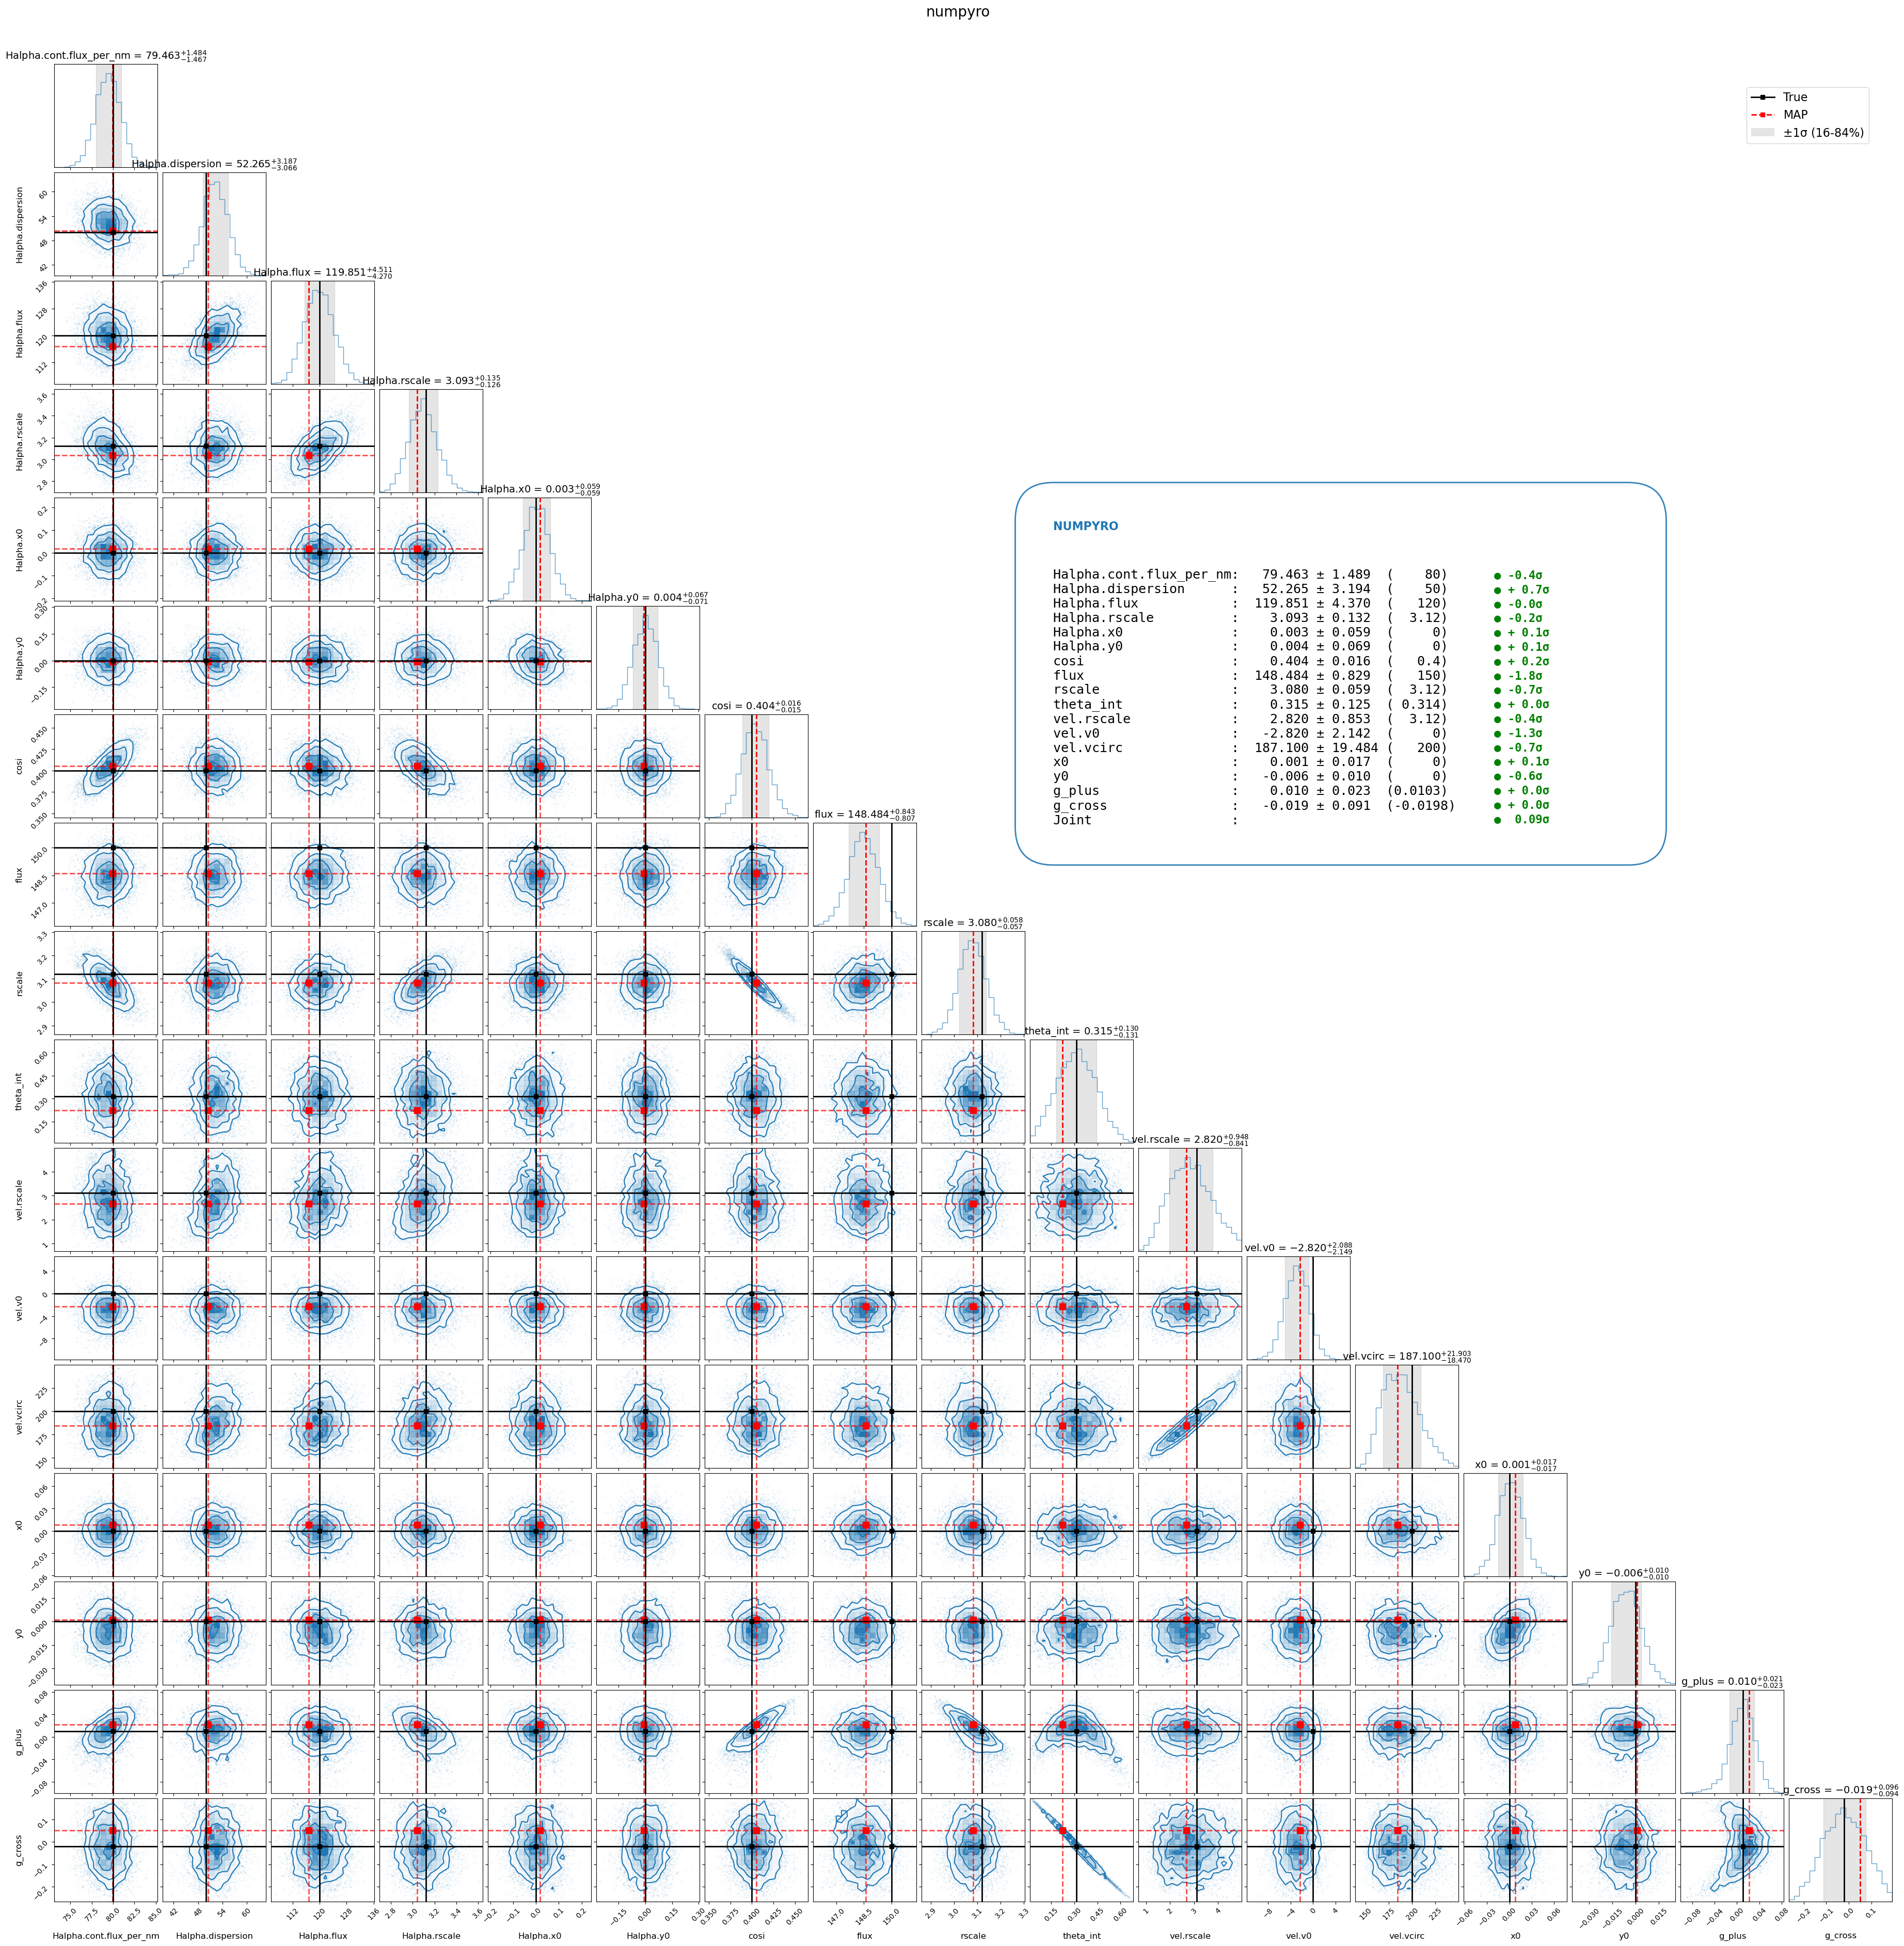

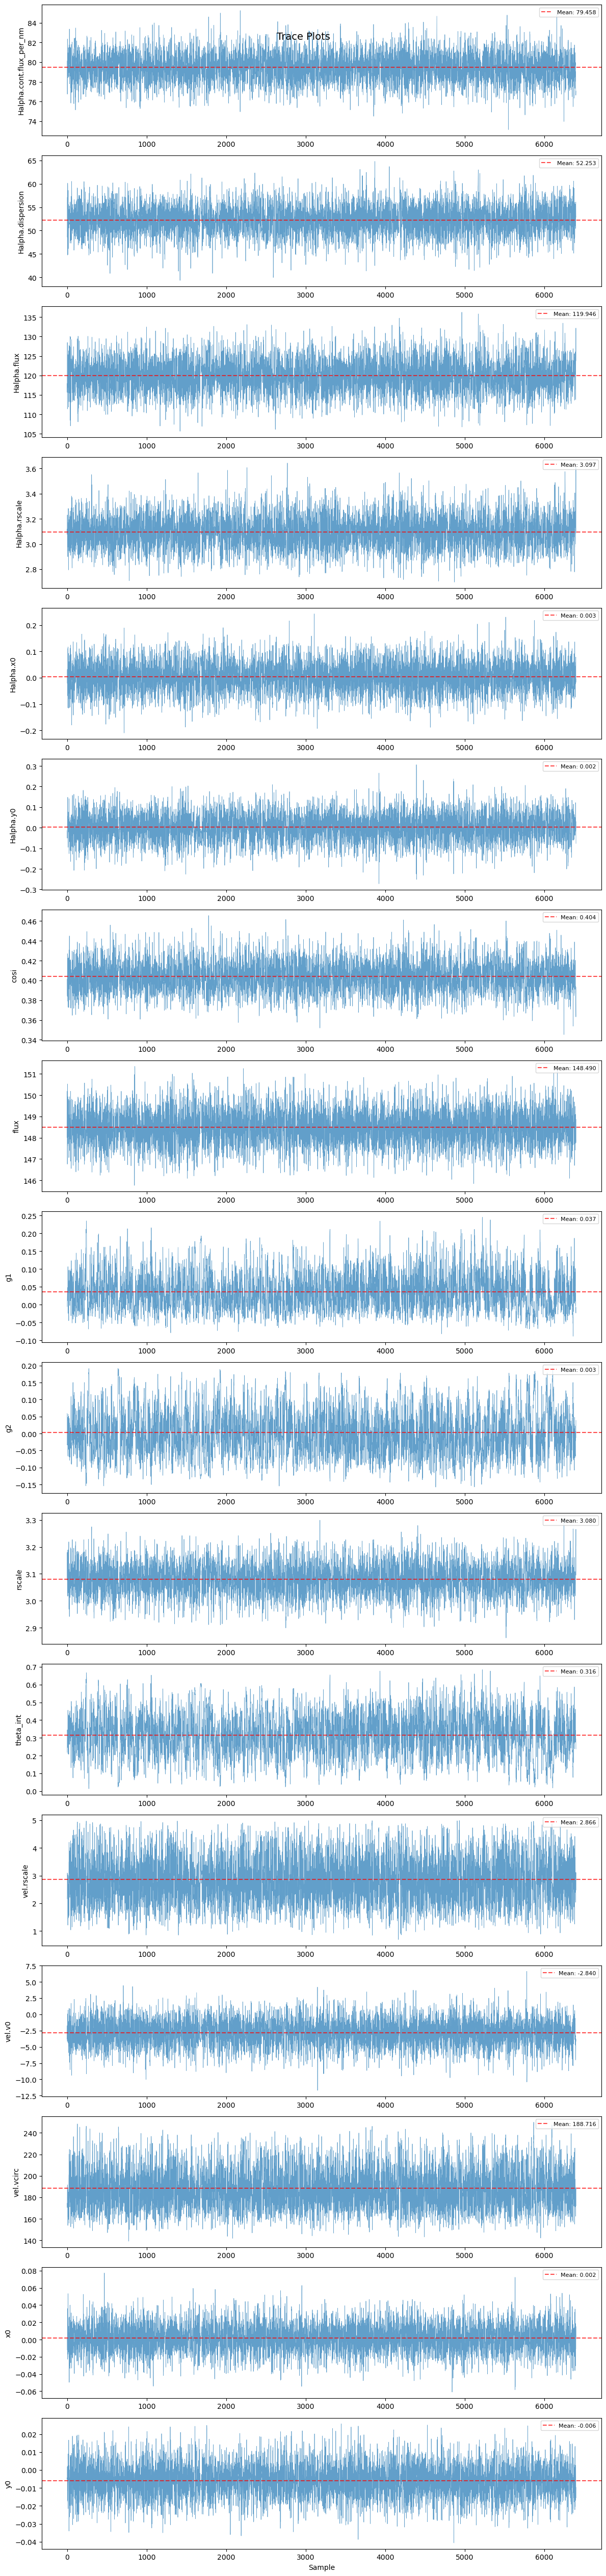

In [74]:
# Corner plot
fig = plot_corner(result, sampler_info={'name': 'numpyro'}, true_values=true_pars)
plt.savefig(folder_name+"/corner.png")
plt.show()

# Trace plots (useful for convergence diagnosis)
fig = plot_trace(result)
plt.savefig(folder_name+"/trace.png")

In [75]:
with open(folder_name+"/configs.txt", "w") as f:
    print(joint_source, file=f)
    imagepars_phot_string = str([str(imagepars.shape),str(imagepars.pixel_scale), str(imagepars.indexing)])
    imagepars_spec_string = str([str(_IMAGE_PARS_spec.shape),str(_IMAGE_PARS_spec.pixel_scale), str(_IMAGE_PARS_spec.indexing)])
    print('imagepars_phot:', imagepars_phot_string, file=f)
    print('imagepars_spec:', imagepars_spec_string, file=f)

    fiber_dict = {'fiber_blur': fiber_blur,
                'fiber_rad': fiber_rad,
                'fiber_offset': fiber_offset,
                'fiber_positions': rotated_offsets,
                #'exposure_offset': EXP_OFFSET,
                #'fiber_exptimes': fiber_exptimes,
                'channel': chn}
    print('fiber configs:', fiber_dict, file=f)
    print('phot_psf:', phot_psf, 'FWHM:', phot_fwhm, file=f)
    print('spec_psf:', spec_psf, 'FWHM:', spec_fwhm, file=f)
    print('render config:', rc, file=f)
    print('true_pars:', true_pars, file=f)
    print('priors:', priors, file=f)

    nuts_config_str = str([config_nuts.n_samples, config_nuts.n_warmup, config_nuts.n_chains, config_nuts.dense_mass, config_nuts.max_tree_depth, config_nuts.target_accept_prob])
    print('nuts config:', nuts_config_str, file=f)
    #nautilus_config_str = str([config_nautilus.n_live, config_nautilus.n_networks, config_nautilus.seed])
    #print('nautilus config:', nautilus_config_str, file=f)